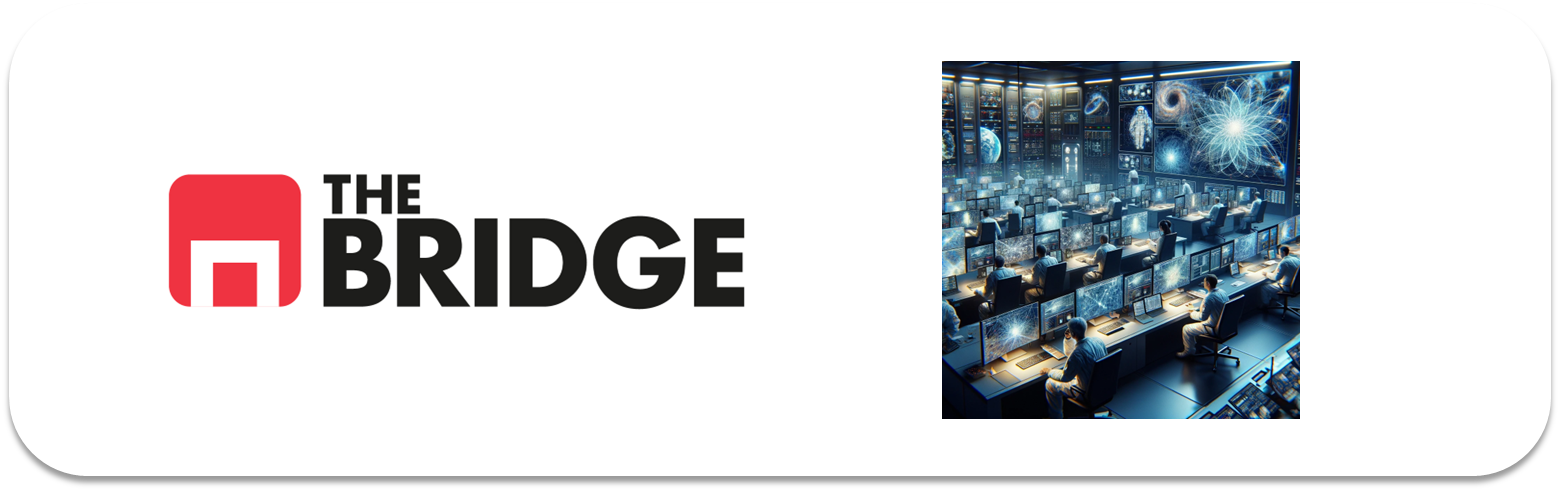

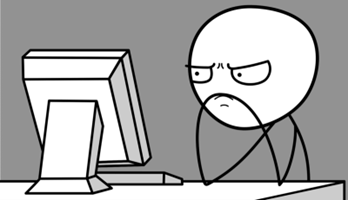

Para ejercitarte y afianzar lo aprendido sobre **Transfer Learning y Fine-tuning**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.base import clone
from threadpoolctl import threadpool_limits
threadpool_limits(2)
SEED=42
np.random.seed(SEED)
ROOT=next(p for p in Path.cwd().parents if (p/'05_Deep_Learning').exists() and (p/'.git').exists())
CACHE=ROOT/'.cache'/'unidades_siguientes'
CACHE.mkdir(parents=True,exist_ok=True)
os.environ['KERAS_HOME']=str(CACHE/'keras')
os.environ['KAGGLEHUB_CACHE']=str(CACHE/'kaggle')
os.environ['TF_CPP_MIN_LOG_LEVEL']='2'
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.keras.utils.set_random_seed(SEED)
tf.config.threading.set_intra_op_parallelism_threads(2)
tf.config.threading.set_inter_op_parallelism_threads(2)
print('TensorFlow:',tf.__version__,'GPUs:',len(tf.config.list_physical_devices('GPU')))
from PIL import Image
import json
def read_images(folder,size=(32,32),labels_from_filename=False):
 folder=Path(folder);files=sorted(p for p in folder.rglob('*') if p.suffix.lower() in ['.jpg','.jpeg','.png'])
 if not files:raise FileNotFoundError(f'Sin imágenes: {folder}')
 images=[];labels=[]
 for p in files:
  with Image.open(p) as img:images.append(np.asarray(img.convert('RGB').resize(size)))
  labels.append(p.name.split('.')[0] if labels_from_filename else p.parent.name)
 return np.asarray(images,dtype=np.uint8),np.asarray(labels),files
def show_images(images,titles=None,indices=None):
 ids=np.arange(min(10,len(images))) if indices is None else np.asarray(indices)[:10]
 if len(ids)==0:print('Sin imágenes que cumplan el criterio.');return
 fig,axes=plt.subplots((len(ids)+4)//5,5,figsize=(15,3*((len(ids)+4)//5)),squeeze=False)
 for ax in axes.flat:ax.axis('off')
 for ax,i in zip(axes.flat,ids):
  ax.imshow(images[i]);ax.set_title(str(titles[i]) if titles is not None else str(i),fontsize=8)
 plt.tight_layout();plt.show()
def plot_history(history):
 h=pd.DataFrame(history.history)
 fig,axes=plt.subplots(1,2,figsize=(12,4))
 h[['loss','val_loss']].plot(ax=axes[0]);h[['accuracy','val_accuracy']].plot(ax=axes[1]);plt.show()
 print('Mejor época val_loss:',int(h.val_loss.argmin())+1,'de',len(h),'gap accuracy final:',float(h.accuracy.iloc[-1]-h.val_accuracy.iloc[-1]))
def evaluate_model(model,X,y,names):
 probs=model.predict(X,batch_size=128,verbose=0)
 if probs.shape[1]==1:
  probs=np.column_stack([1-probs[:,0],probs[:,0]])
 pred=probs.argmax(axis=1)
 print(classification_report(y,pred,labels=np.arange(len(names)),target_names=names,zero_division=0))
 fig,ax=plt.subplots(figsize=(9,8));ConfusionMatrixDisplay.from_predictions(y,pred,display_labels=names,normalize='true',ax=ax,xticks_rotation=60);plt.show()
 return {'accuracy':accuracy_score(y,pred),'balanced_accuracy':balanced_accuracy_score(y,pred)},probs
def callbacks(patience=4):return [keras.callbacks.EarlyStopping(monitor='val_loss',patience=patience,restore_best_weights=True)]
from tensorflow.keras.applications.resnet_v2 import ResNet50V2,decode_predictions,preprocess_input
from sklearn.utils import shuffle
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Model


TensorFlow: 2.21.0 GPUs: 0


## Apple 360

En este conjunto de ejercicios vas a montar un clasificador de manzanas mediante un dataset de imágenes. El dataset se compone de 13 tipos diferentes con aproximadamente unas 200 imágenes por cada tipo. Tendrás que montar un modelo de deep learning que utilice **transfer learning**. Se sugiere empezar con una red ResNet50 con imagenet.

El dataset original proviene del [concurso de Kaggle Fruits 360](https://www.kaggle.com/moltean/fruits), pero adaptado para la clasificación de una menor cantidad de casos (sólo las manzanas).


### Ejercicio 1

Crea los juegos de X,y para train y test a partir de los datos teninendo en cuenta su distribución, para ello tendrás que explorar las estructura. Crea un juego Train,test para resolución 32x32 y un juego de test adicional para 224x224. Es decir tendras que tener un X_train, X_test para 32x32 y un X_test adicional a 224x224

In [2]:
TRAIN_PATH=Path('data/apples/Train');TEST_PATH=Path('data/apples/Test')
X_train,y_train,train_files=read_images(TRAIN_PATH)
X_test,y_test,test_files=read_images(TEST_PATH)
X_test_224,y_test_224,_=read_images(TEST_PATH,(224,224))
print(X_train.shape,X_test.shape)

(6404, 32, 32, 3) (2134, 32, 32, 3)


**NOTA:** A partir de aquí emplea siempre el X_train, X_test de 32x32 salvo en el ejercicio que se te diga lo contrario.

### Ejercicio 2

Haz una visualización de algunos de los datos. Crea una función que te ayude con ello.

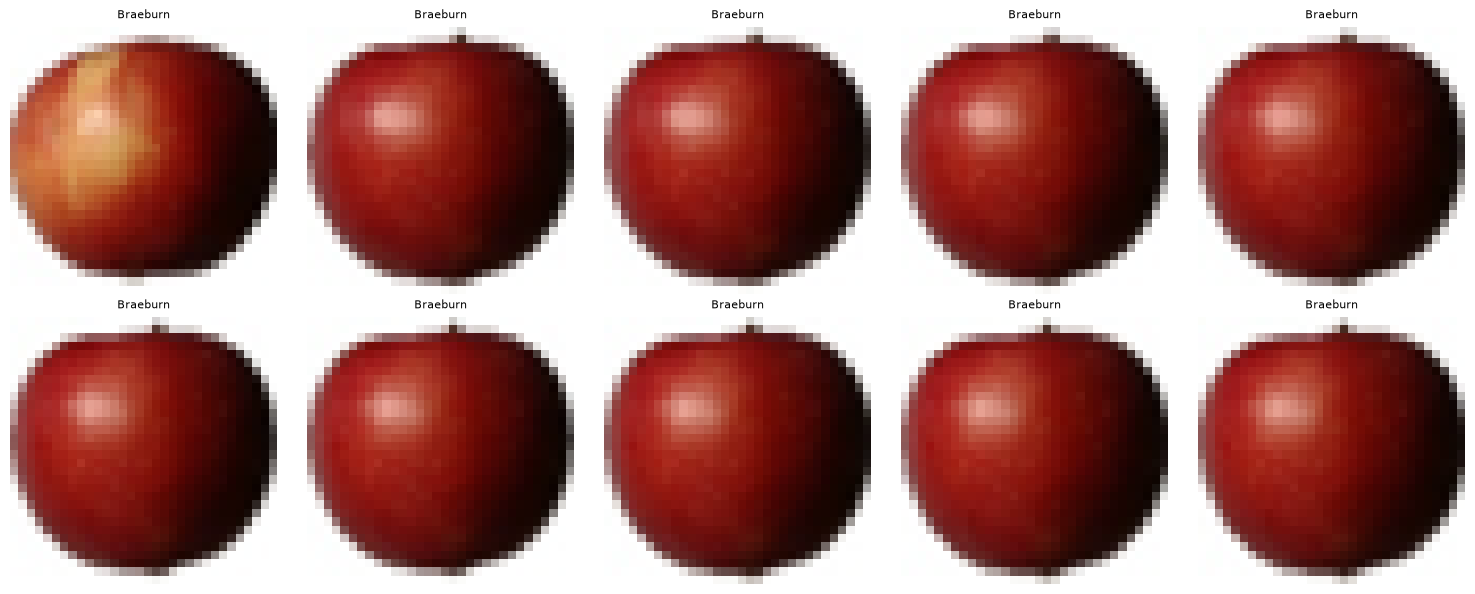

In [3]:
def show_images_batch(images,names=None,**kwargs):
 show_images(np.clip((images+1)*127.5,0,255).astype('uint8') if images.dtype.kind=='f' else images,names)
show_images(X_train,y_train)

### Ejercicio 3

Completa el miniEDA habitual con imágenes y escoge una métrica para el modelo.

In [4]:
pd.Series(y_train).value_counts(normalize=True)


RedYellow2      0.104934
Braeburn        0.076827
Golden2         0.076827
GrannySmith     0.076827
Red1            0.076827
Red2            0.076827
RedYellow1      0.076827
RedDelicious    0.076515
Golden3         0.075109
Golden1         0.074953
PinkLady        0.071205
CrimsonSnow     0.069332
Red3            0.066989
Name: proportion, dtype: float64

### Ejercicio 4 

Termina de transformar los datos si crees que es conveniente y aunque el entrenamiento de modelos de keras ya tiene un shuffling interno, haz un "barajado" del X_train (del X_test no es necesario) para facilitar la convergencia inicial del modelo. Utiliza la función shuffle de sklearn y asigna la salida a un X_train distinto (es decir no machaques el inicial)

In [5]:
X_train=preprocess_input(X_train.astype('float32'));X_test=preprocess_input(X_test.astype('float32'));X_test_224=preprocess_input(X_test_224.astype('float32'))
X_train_s,y_train_s=shuffle(X_train,y_train,random_state=SEED)

### Ejercicio 5

Sklearn permite trabajar con etiquetas textuales pero keras no. Transforma las etiquetas a numéricas, creando dos diccionarios uno que permita traducir de etiqueta a clase numérica y otro que permita la transformación inversa.

In [6]:
# Mapeamos las categorías a números
categorias = np.unique(y_train)
n_categorias = len(categorias)

mapping = {cat: i for i, cat in enumerate(categorias)}
inverse_mapping = {valor: clave for clave, valor in mapping.items()}

print("Número de categorías:", n_categorias)
print("Mapping:", mapping)

y_train_num = np.array([mapping[cat] for cat in y_train_s])
y_test_num = np.array([mapping[cat] for cat in y_test])


Número de categorías: 13
Mapping: {np.str_('Braeburn'): 0, np.str_('CrimsonSnow'): 1, np.str_('Golden1'): 2, np.str_('Golden2'): 3, np.str_('Golden3'): 4, np.str_('GrannySmith'): 5, np.str_('PinkLady'): 6, np.str_('Red1'): 7, np.str_('Red2'): 8, np.str_('Red3'): 9, np.str_('RedDelicious'): 10, np.str_('RedYellow1'): 11, np.str_('RedYellow2'): 12}


### Ejercicio 6: Zero Shot Learning

Descar el modelo ResNet50 preparado ya para poder usarlo directamente a la Zero Shot Learning. Pruébalo contra el test (aquí no valen nuestras categorías serán las que proporcione ResNet ojo). Prueba una selección aleatoria de imágenes del test y compara las etiquetas de ResNet con la que tiene. ¿Nos sirve este clasificador así tal cual?

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


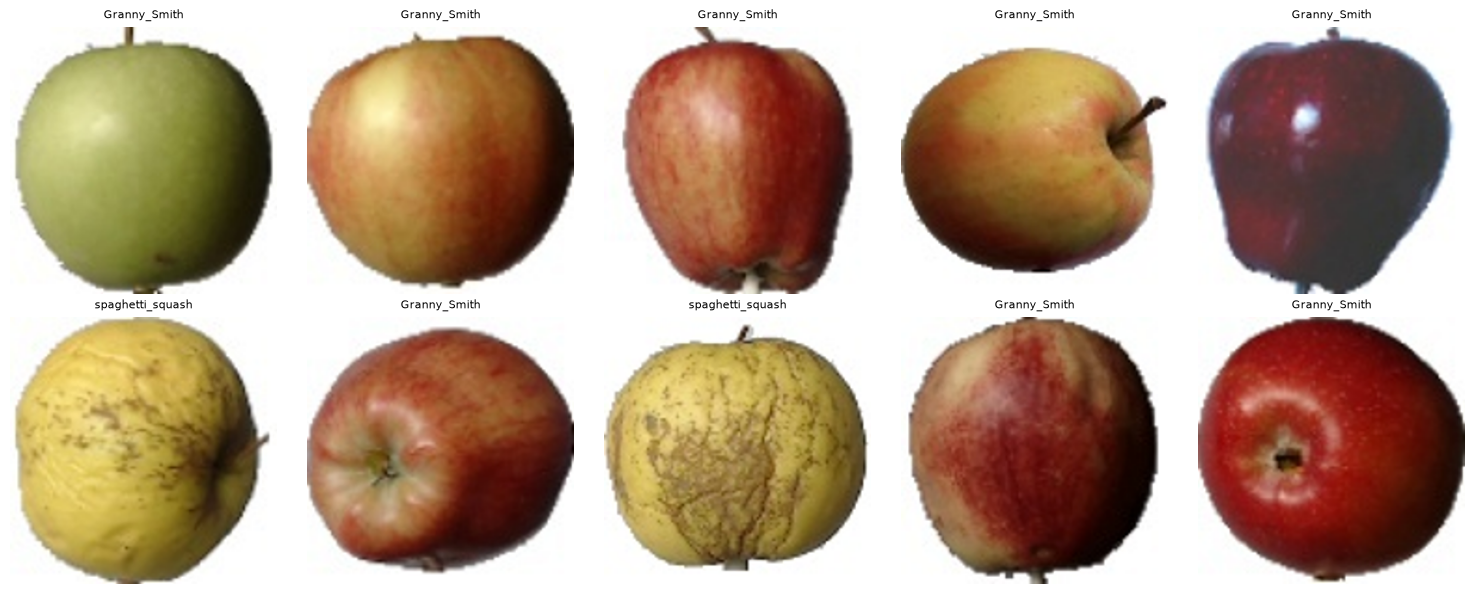

In [7]:
# Zero Shot Learning: usamos ResNet50V2 preentrenada en ImageNet con cabeza de clasificación
base_model_zsl = ResNet50V2(include_top=True, weights='imagenet', input_shape=(224, 224, 3))

# Seleccionamos 20 imágenes de test al azar y predecimos
seleccion = np.random.randint(0, len(X_test_224), 20)
predictions_zsl = base_model_zsl.predict(X_test_224[seleccion])

# Decodificamos las predicciones de ImageNet
clase_zsl = [decodificado[0][1] for decodificado in decode_predictions(predictions_zsl)]
show_images_batch(X_test_224[seleccion], names=clase_zsl)


## Transfer Learning

### Ejercicio 7:

Carga la ResNet50 sin cabezas, crea un modelo con el anterior y una cabeza con dos capas densas, una oculta de 300 unidades (con activación "relu") y otra de salida con las unidades que crees necesarias y activación la que consideres. Congela las capas del modelo base (la ResNet50). Define también los hiperparámetros necesarios para compilar y compila el modelo y muestra un summary del mismo.

In [8]:
# Transfer Learning: ResNet50V2 preentrenada (imagenet), cabeza personalizada
base_model = ResNet50V2(include_top=False, weights='imagenet', input_shape=(32, 32, 3))

# Congelamos las capas del modelo base
for layer in base_model.layers:
    layer.trainable = False

def prepare_model(base_model=base_model):
    x = layers.Flatten()(base_model.output)
    x = layers.Dense(300, activation='relu')(x)
    x = layers.Dropout(rate=0.5)(x)
    x = layers.Dense(n_categorias, activation='softmax')(x)
    model = Model(base_model.input, x)
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['acc'])
    return model

model = prepare_model()
model.summary()

earlyS = EarlyStopping(patience=5, restore_best_weights=True)
batch_size = 64


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 8, 8, 64)  │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 8, 8, 64)  │          0 │ conv2_block1_pre… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 10, 10,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 8, 8, 256) │          0 │ conv2_block1_0_c

 Total params: 24,183,413 (92.25 MB)

 Trainable params: 618,613 (2.36 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

### Ejercicio 8

Entrena el modelo con nuestros datos de train y muestra la evolución del entrenamiento. Emplea un callback de Earlystopping con patience a 5. Termina de escoger el batch_size y el número de épocas.

Epoch 1/20


 1/81 ━━━━━━━━━━━━━━━━━━━━ 4:39 3s/step - acc: 0.1250 - loss: 5.8258

 2/81 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - acc: 0.0938 - loss: 5.3687

 3/81 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - acc: 0.1250 - loss: 4.6855 

 4/81 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step - acc: 0.1328 - loss: 4.3965

...

77/81 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - acc: 0.9923 - loss: 0.0221

78/81 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - acc: 0.9922 - loss: 0.0224

79/81 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - acc: 0.9923 - loss: 0.0223

80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - acc: 0.9924 - loss: 0.0221

81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 162ms/step - acc: 0.9924 - loss: 0.0221 - val_acc: 1.0000 - val_loss: 0.0029


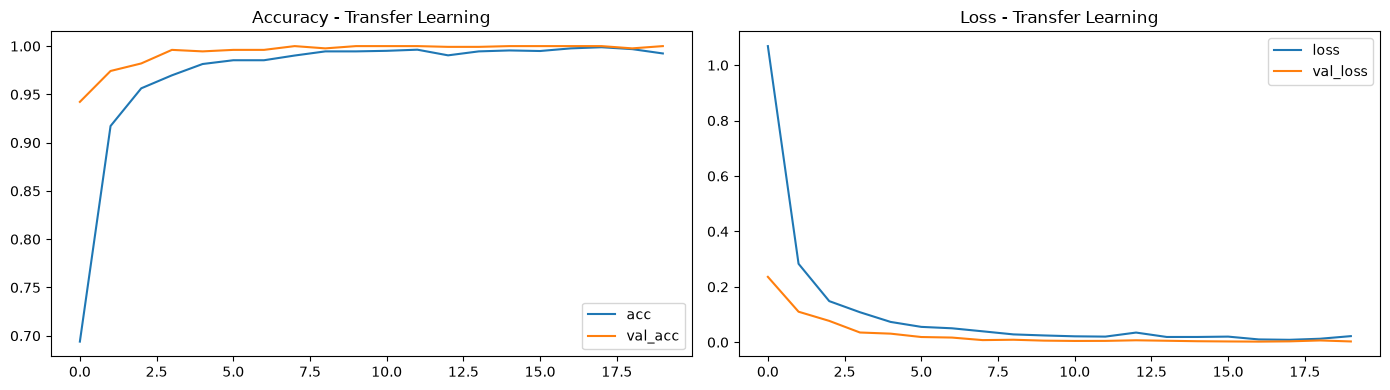

In [9]:
# Entrenamos el modelo de Transfer Learning
model = prepare_model()
history = model.fit(X_train_s,
                    y_train_num,
                    batch_size=batch_size,
                    validation_split=0.2,
                    epochs=20,
                    callbacks=[earlyS])

# Visualizamos la evolución del entrenamiento
evol = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
evol[['acc', 'val_acc']].plot(ax=axes[0])
axes[0].set_title('Accuracy - Transfer Learning')
evol[['loss', 'val_loss']].plot(ax=axes[1])
axes[1].set_title('Loss - Transfer Learning')
plt.tight_layout()
plt.show()


### Ejercicio 9

Evalua el modelo contra test y haz un pequeño análisis de las diferencias. Haz un clasification report y muestra la matriz de confusion. Haz un pequeño análisis de errores.

 1/67 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - acc: 0.9062 - loss: 0.1546

 2/67 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - acc: 0.9531 - loss: 0.0847

 3/67 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - acc: 0.9062 - loss: 0.1675

 4/67 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - acc: 0.8047 - loss: 0.4636

 5/67 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - acc: 0.7312 - loss: 0.8989

...

65/67 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

66/67 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step

67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step


              precision    recall  f1-score   support

    Braeburn       0.95      0.74      0.83       164
 CrimsonSnow       0.94      0.93      0.94       148
     Golden1       0.86      1.00      0.93       160
     Golden2       0.97      0.88      0.92       164
     Golden3       0.67      0.74      0.70       161
 GrannySmith       0.95      0.89      0.92       164
    PinkLady       0.93      0.87      0.90       152
        Red1       1.00      0.77      0.87       164
        Red2       0.64      0.93      0.76       164
        Red3       0.97      0.97      0.97       144
RedDelicious       1.00      1.00      1.00       166
  RedYellow1       0.92      0.91      0.92       164
  RedYellow2       1.00      0.99      0.99       219

    accuracy                           0.90      2134
   macro avg       0.91      0.89      0.90      2134
weighted avg       0.91      0.90      0.90      2134



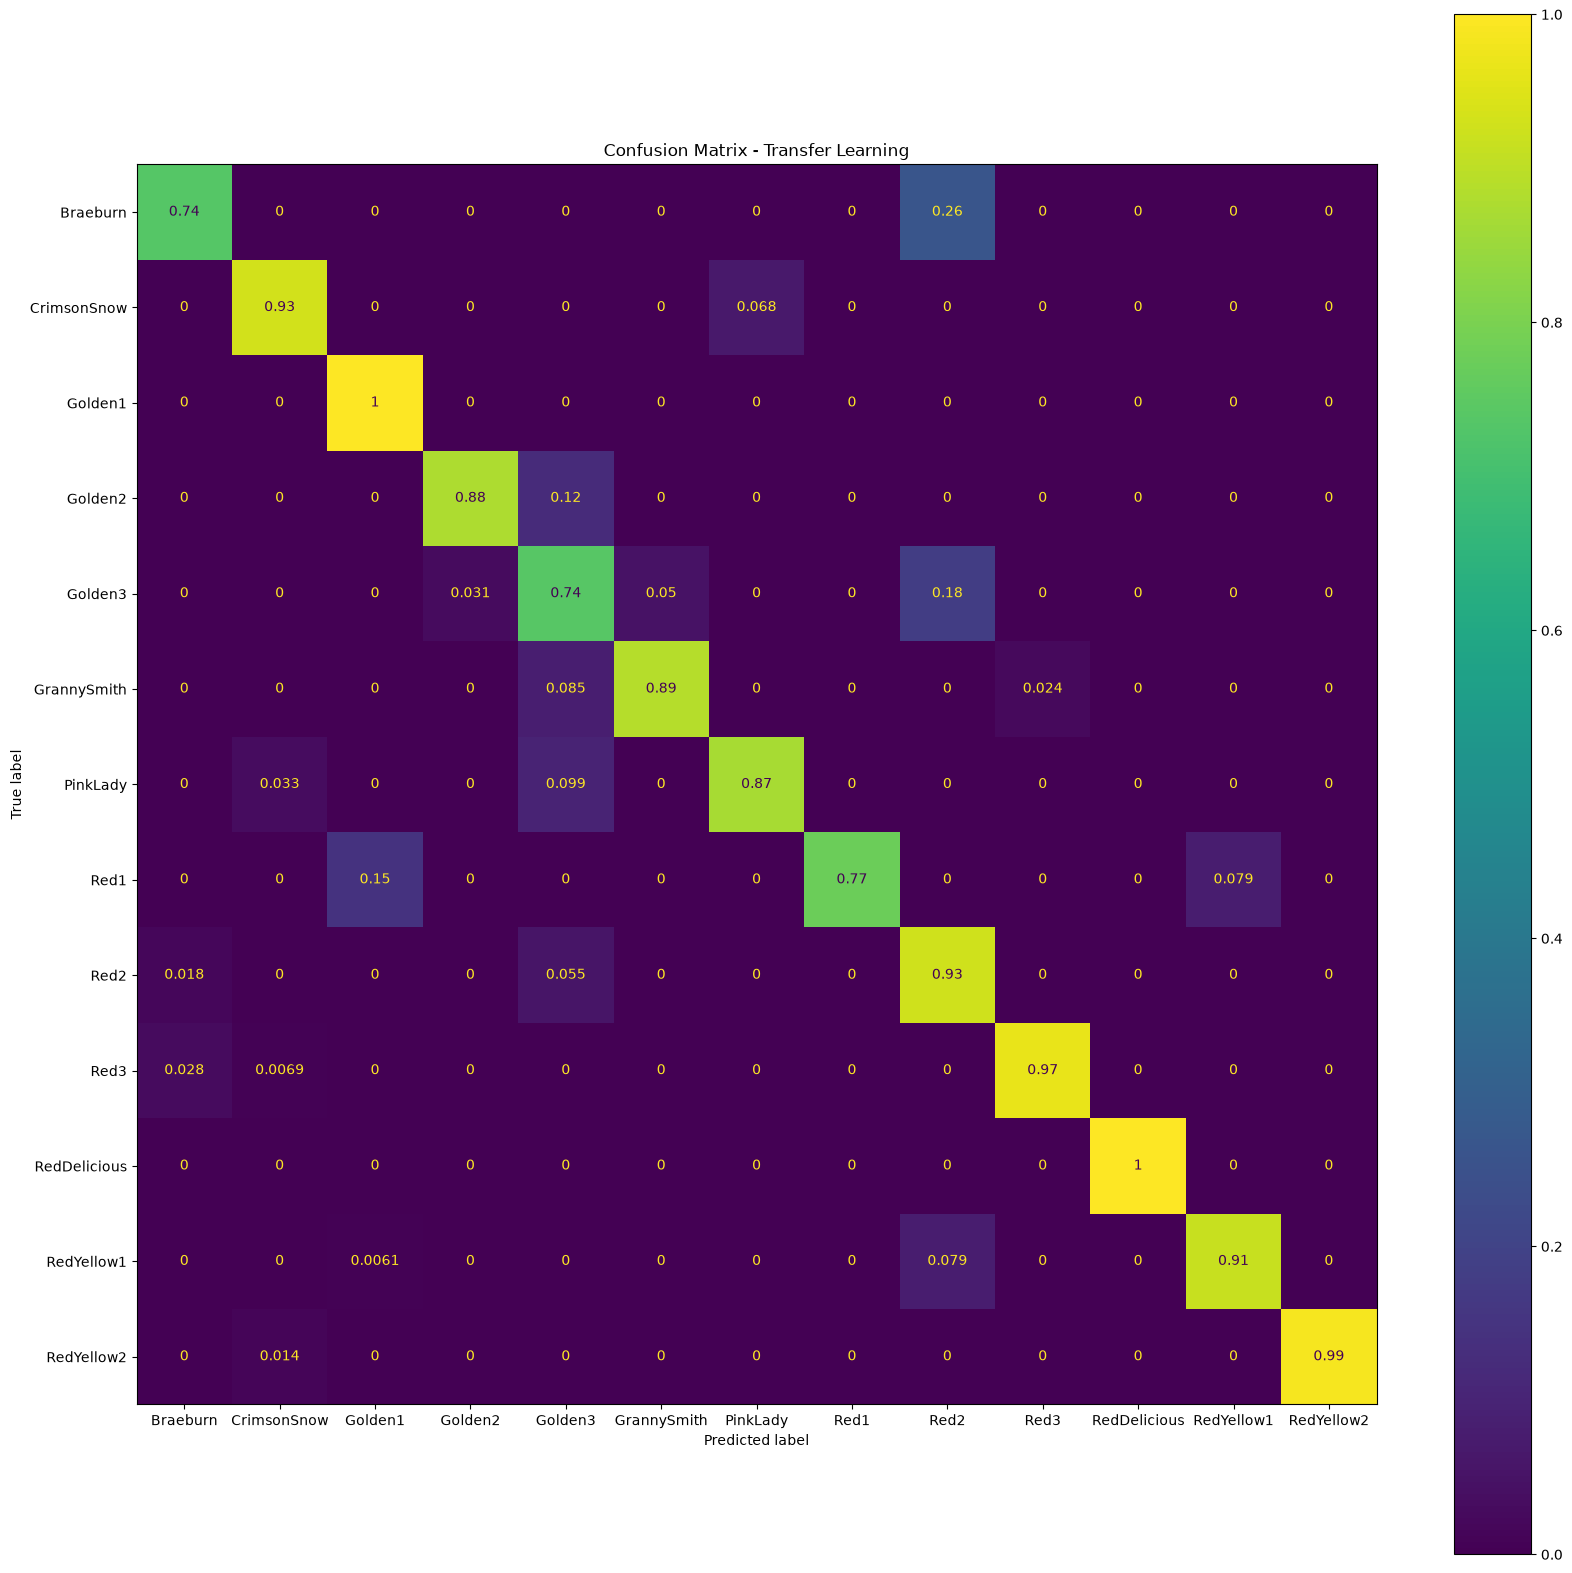

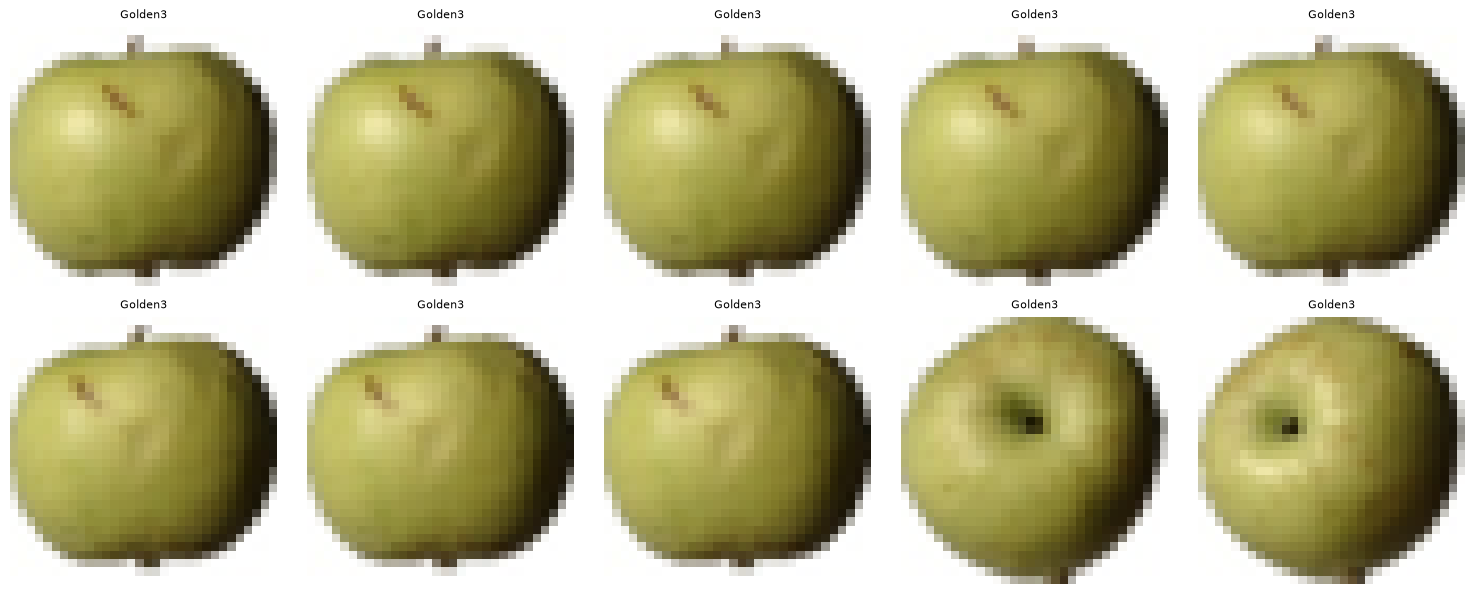

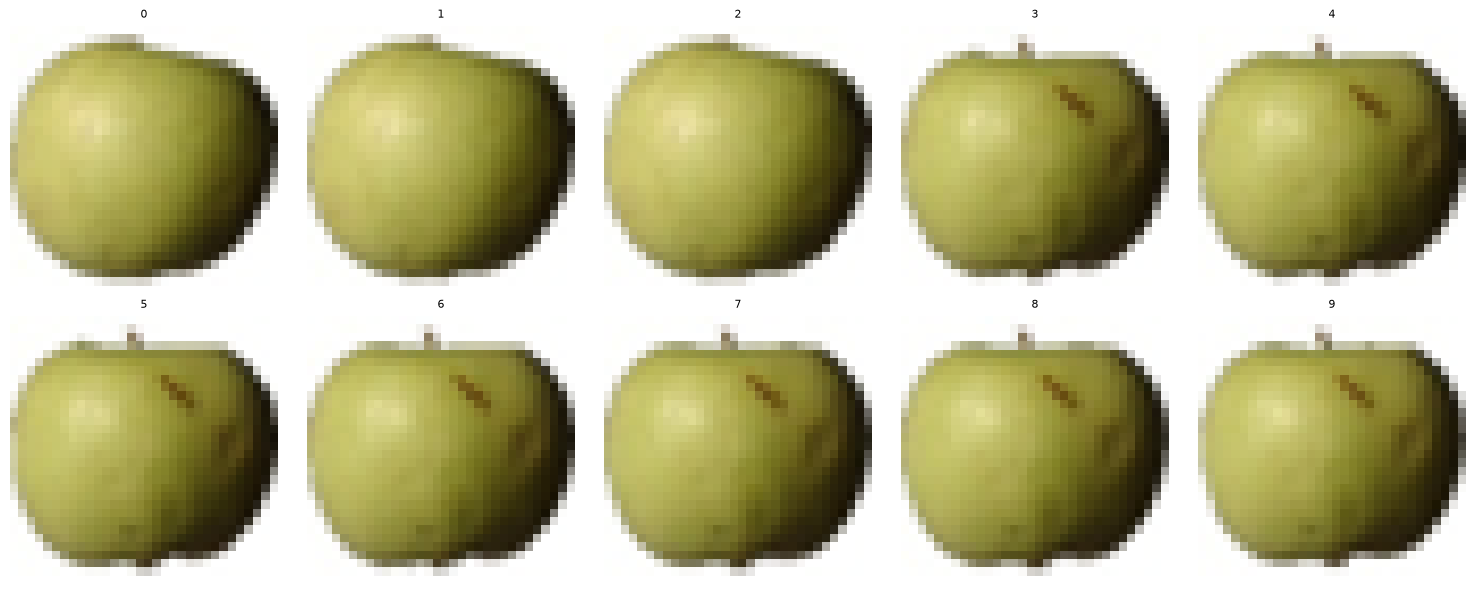

In [10]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Evaluamos el modelo en test
model.evaluate(X_test, y_test_num)

# Predicciones
y_pred = [inverse_mapping[np.argmax(pred)] for pred in model.predict(X_test)]
print(classification_report(y_test, y_pred))

# Matriz de confusión normalizada
fig, axs = plt.subplots(1, 1, figsize=(20, 20))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize='true', ax=axs)
plt.title('Confusion Matrix - Transfer Learning')
plt.show()

# Análisis de errores: errores entre clases más confundidas
resultados = pd.DataFrame({'True': y_test, 'Predicted': y_pred})
errores = resultados['True'] != resultados['Predicted']

# Mostramos imágenes de manzanas Golden3 predichas como Red2
es_Golden3 = resultados['True'] == 'Golden3'
predicted_Red2 = resultados['Predicted'] == 'Red2'
show_images_batch(X_test[resultados[es_Golden3 & predicted_Red2].index],
                  y_test[resultados[es_Golden3 & predicted_Red2].index])

# Mostramos predicciones correctas de Golden3 para comparar
show_images_batch(X_test[resultados[es_Golden3 & (errores == False)].index[0:10]])


## Fine Tuning

### Ejercicio 10

Vuelve a descargar el modelo ResNet50 pero sin pesos entrenados, ni cabeza, crea el mismo modelo personalizado que en el ejercicio 7, compila y muestra el summary.

In [11]:
# Conservamos el modelo entrenado y su cabeza; descongelamos el último bloque.
base_model.trainable=True
for layer in base_model.layers[:-30]:layer.trainable=False
for layer in base_model.layers:
 if isinstance(layer,layers.BatchNormalization):layer.trainable=False
model.compile(optimizer=keras.optimizers.Adam(1e-5),loss='sparse_categorical_crossentropy',metrics=['acc'])
earlySFT=EarlyStopping(patience=4,restore_best_weights=True)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 8, 8, 64)  │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 8, 8, 64)  │          0 │ conv2_block1_pre… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 10, 10,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 8, 8, 256) │          0 │ conv2_block1_0_c

 Total params: 24,183,413 (92.25 MB)

 Trainable params: 618,613 (2.36 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

### Ejercicio 11
Entrena con batch_size a 64 y 60 épocas, con un EarlyStopping de patience a 10 (ahora el entrenamiento es sensiblemente más largo, así que tómate un descanso). Muestra la evolución y da una posible justificación a emplear tantas épocas de partida.

Epoch 1/12


 1/81 ━━━━━━━━━━━━━━━━━━━━ 5:08 4s/step - acc: 1.0000 - loss: 0.0049

 2/81 ━━━━━━━━━━━━━━━━━━━━ 11s 144ms/step - acc: 1.0000 - loss: 0.0071

 3/81 ━━━━━━━━━━━━━━━━━━━━ 11s 150ms/step - acc: 1.0000 - loss: 0.0080

 4/81 ━━━━━━━━━━━━━━━━━━━━ 11s 144ms/step - acc: 1.0000 - loss: 0.0094

...

77/81 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - acc: 0.9988 - loss: 0.0052

78/81 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - acc: 0.9988 - loss: 0.0052

79/81 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - acc: 0.9988 - loss: 0.0052

80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - acc: 0.9988 - loss: 0.0052

81/81 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step - acc: 0.9988 - loss: 0.0052 - val_acc: 1.0000 - val_loss: 0.0013


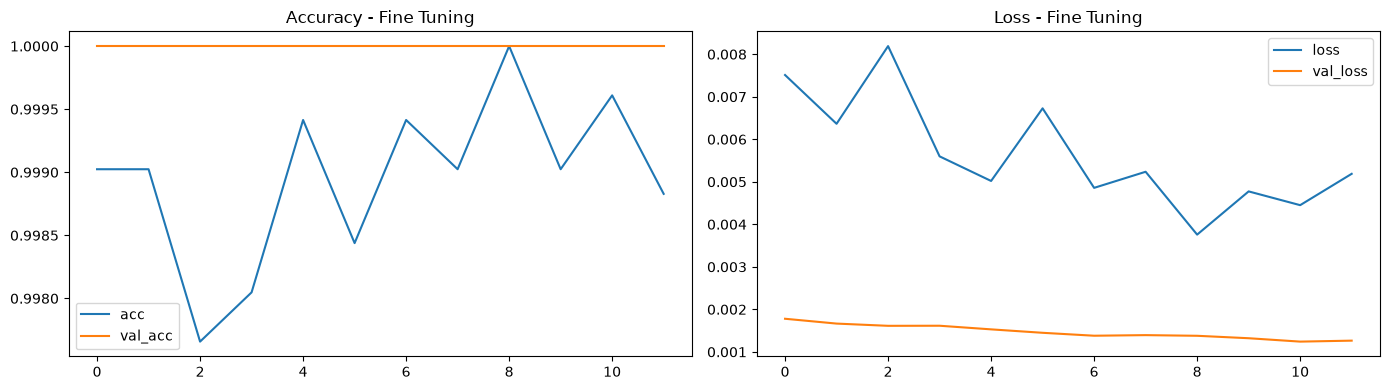

In [12]:
# Entrenamos el modelo de Fine Tuning (más épocas, más paciencia)

history = model.fit(X_train_s,
                    y_train_num,
                    batch_size=batch_size,
                    validation_split=0.2,
                    epochs=12,
                    callbacks=[earlySFT])

# Evolución del entrenamiento
df_evol = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_evol[['acc', 'val_acc']].plot(ax=axes[0])
axes[0].set_title('Accuracy - Fine Tuning')
df_evol[['loss', 'val_loss']].plot(ax=axes[1])
axes[1].set_title('Loss - Fine Tuning')
plt.tight_layout()
plt.show()


### Ejercicio 12

Muestra la evaluación contra el test, el informe de clasificación  y la matriz de confusión. Compara los resultados con los del ejercicio 9.

 1/67 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - acc: 0.9688 - loss: 0.0553

 2/67 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - acc: 0.9844 - loss: 0.0291

 3/67 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - acc: 0.9583 - loss: 0.0691

 4/67 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - acc: 0.8594 - loss: 0.2746

 5/67 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - acc: 0.7812 - loss: 0.6458

...

65/67 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step

66/67 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step


              precision    recall  f1-score   support

    Braeburn       0.93      0.79      0.85       164
 CrimsonSnow       0.91      0.94      0.93       148
     Golden1       0.86      1.00      0.93       160
     Golden2       0.97      0.87      0.92       164
     Golden3       0.69      0.75      0.72       161
 GrannySmith       0.98      0.88      0.93       164
    PinkLady       0.92      0.87      0.89       152
        Red1       1.00      0.77      0.87       164
        Red2       0.65      0.87      0.74       164
        Red3       0.96      0.99      0.98       144
RedDelicious       1.00      1.00      1.00       166
  RedYellow1       0.92      0.93      0.92       164
  RedYellow2       1.00      0.99      0.99       219

    accuracy                           0.90      2134
   macro avg       0.91      0.90      0.90      2134
weighted avg       0.91      0.90      0.90      2134



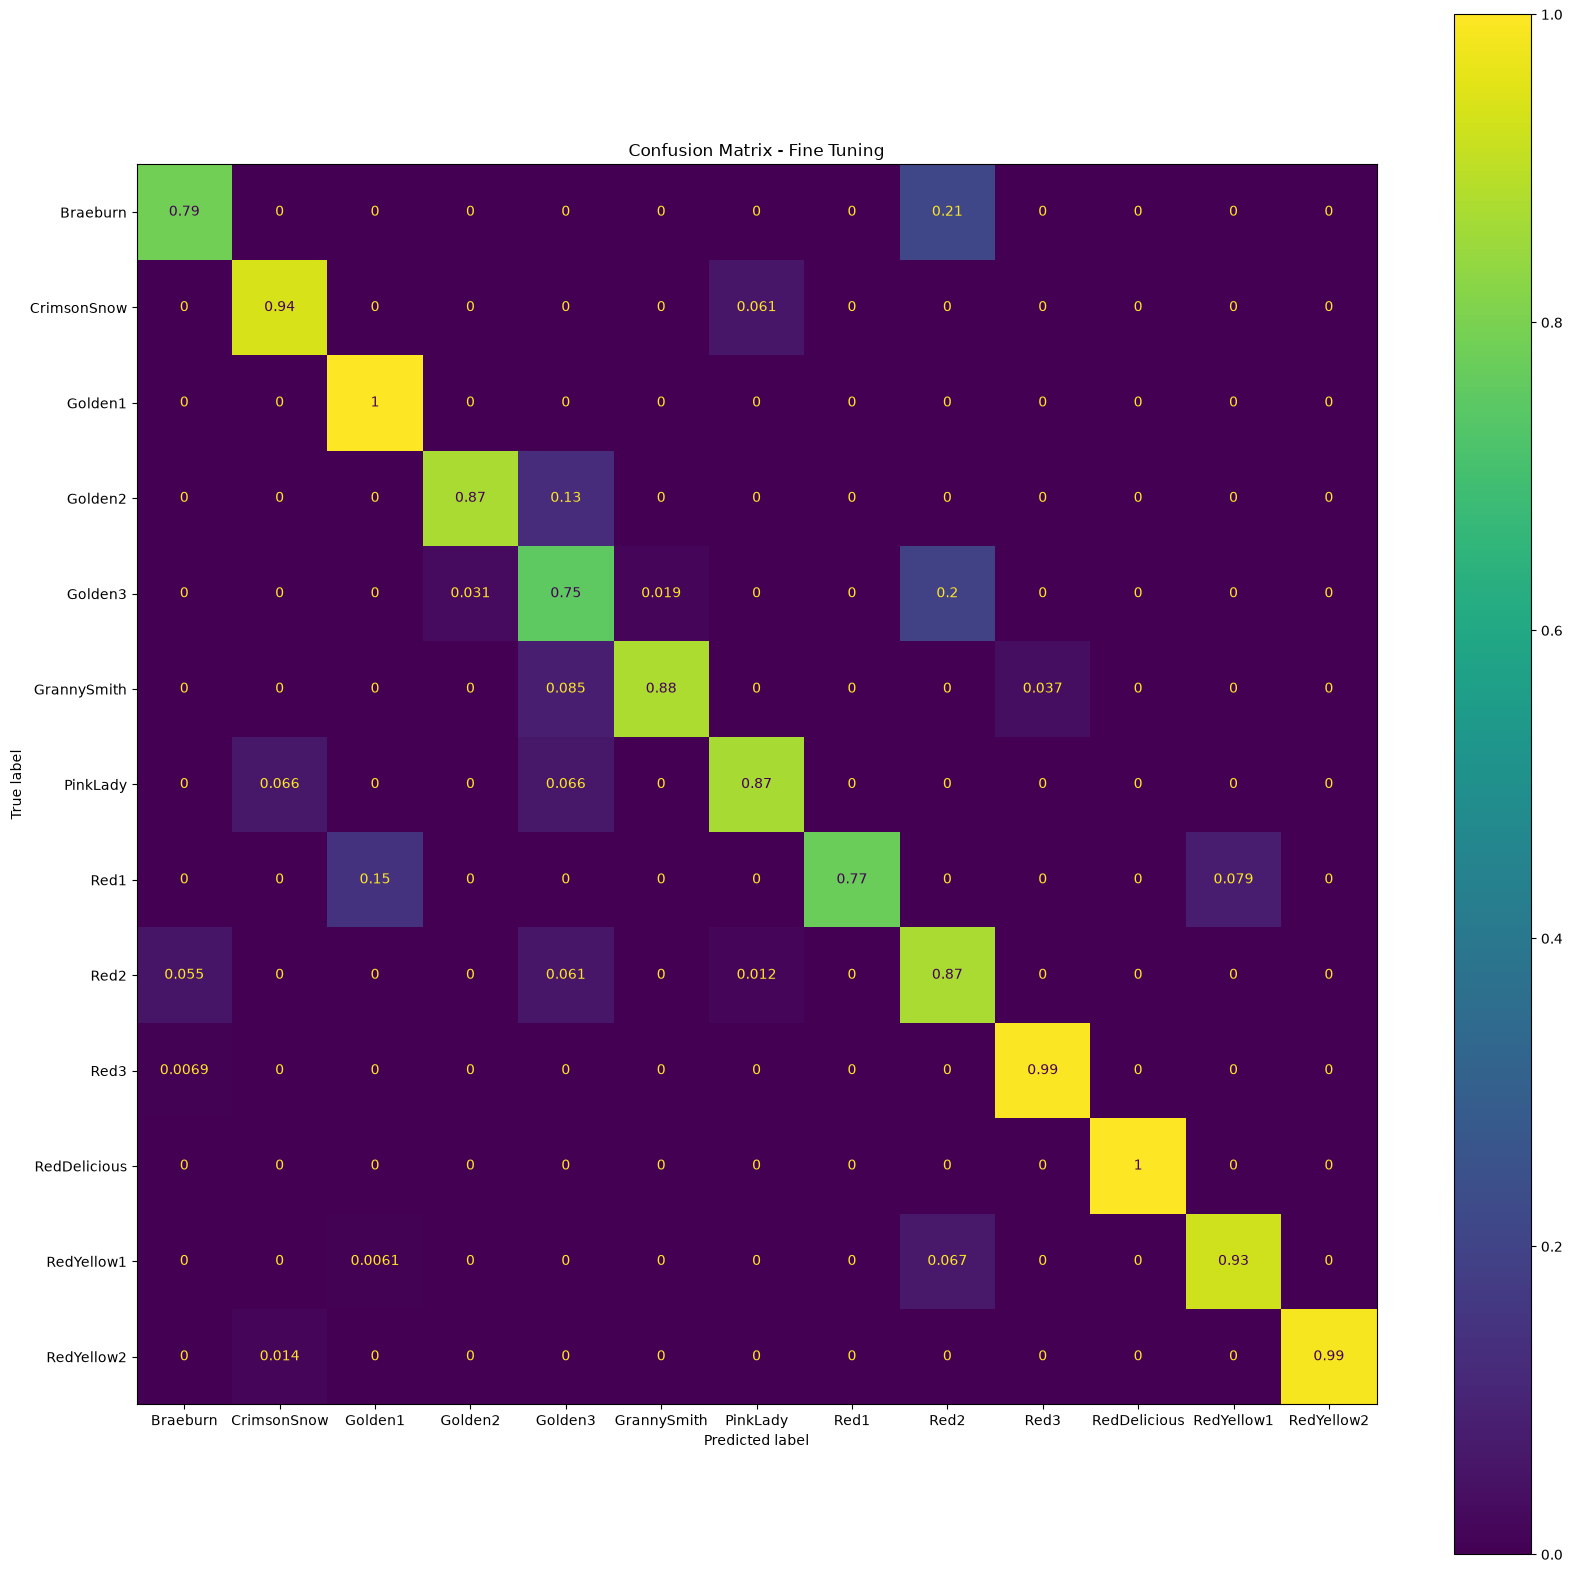

In [13]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Evaluamos el modelo de Fine Tuning en test
model.evaluate(X_test, y_test_num)

# Predicciones
y_pred = [inverse_mapping[np.argmax(pred)] for pred in model.predict(X_test)]
print(classification_report(y_test, y_pred))

# Matriz de confusión normalizada
fig, axs = plt.subplots(1, 1, figsize=(20, 20))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize='true', ax=axs)
plt.title('Confusion Matrix - Fine Tuning')
plt.show()
